# 05 — Problemas de Satisfacción de Restricciones

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- representar un CSP mediante variables, dominios y restricciones;
- resolver un problema de horarios con backtracking;
- medir el efecto de MRV, heurística de grado y forward checking;
- diferenciar satisfacción de restricciones y optimización.

![Descripción](https://drive.google.com/uc?export=view&id=1opAXyVoZi8Orca1oSZ3zRk-vG_d868c1)



## 1. Programación de exámenes

Siete exámenes deben asignarse a tres días. Algunos pares comparten estudiantes y no pueden programarse el mismo día.

Un CSP se define por:

- variables $X_1,\dots,X_n$;
- dominios $D_1,\dots,D_n$;
- restricciones que determinan qué asignaciones son válidas.

In [1]:
from collections import defaultdict
import matplotlib.pyplot as plt

VARIABLES = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
DAYS = ['Lunes', 'Martes', 'Miércoles']
CONSTRAINTS = [
    ('A', 'B'), ('A', 'C'), ('B', 'C'), ('B', 'D'), ('B', 'E'),
    ('C', 'E'), ('C', 'F'), ('D', 'E'), ('E', 'F'), ('E', 'G'),
    ('F', 'G')
]

neighbors = defaultdict(set)
for x, y in CONSTRAINTS:
    neighbors[x].add(y)
    neighbors[y].add(x)

print('Vecinos por variable:')
for var in VARIABLES:
    print(var, sorted(neighbors[var]))

Vecinos por variable:
A ['B', 'C']
B ['A', 'C', 'D', 'E']
C ['A', 'B', 'E', 'F']
D ['B', 'E']
E ['B', 'C', 'D', 'F', 'G']
F ['C', 'E', 'G']
G ['E', 'F']


## 2. Consistencia

Una asignación parcial es consistente cuando ningún par ya asignado viola una restricción.

In [2]:
def consistent(assignment):
    for x, y in CONSTRAINTS:
        if x in assignment and y in assignment and assignment[x] == assignment[y]:
            return False
    return True

print(consistent({'A': 'Lunes', 'B': 'Martes'}))
print(consistent({'A': 'Lunes', 'B': 'Lunes'}))

True
False


## 3. Backtracking básico

Construimos la asignación una variable a la vez. Cuando una elección conduce a una contradicción, retrocedemos.

In [3]:
def backtracking_basic(variables, domains):
    stats = {'calls': 0, 'failures': 0}

    def backtrack(assignment):
        stats['calls'] += 1
        if len(assignment) == len(variables):
            return assignment.copy()

        var = next(v for v in variables if v not in assignment)
        for value in domains[var]:
            assignment[var] = value
            if consistent(assignment):
                result = backtrack(assignment)
                if result is not None:
                    return result
            assignment.pop(var)

        stats['failures'] += 1
        return None

    return backtrack({}), stats

domains = {var: DAYS.copy() for var in VARIABLES}
solution_basic, stats_basic = backtracking_basic(VARIABLES, domains)
print('Solución:', solution_basic)
print('Estadísticas:', stats_basic)

Solución: {'A': 'Lunes', 'B': 'Martes', 'C': 'Miércoles', 'D': 'Miércoles', 'E': 'Lunes', 'F': 'Martes', 'G': 'Miércoles'}
Estadísticas: {'calls': 9, 'failures': 1}


## 4. MRV y heurística de grado

**MRV** selecciona la variable no asignada con menos valores disponibles. En caso de empate, la heurística de grado prioriza la variable que restringe a más variables no asignadas.

In [4]:
def legal_values(var, assignment, domains):
    return [value for value in domains[var]
            if all(assignment.get(n) != value for n in neighbors[var])]


def select_unassigned_variable(assignment, domains):
    unassigned = [v for v in VARIABLES if v not in assignment]
    return min(
        unassigned,
        key=lambda v: (
            len(legal_values(v, assignment, domains)),
            -sum(n not in assignment for n in neighbors[v])
        )
    )

assignment = {'A': 'Lunes'}
print('Siguiente variable:', select_unassigned_variable(assignment, domains))

Siguiente variable: B


## 5. Forward Checking

Después de asignar una variable, eliminamos ese valor de los dominios de sus vecinos no asignados. Si algún dominio queda vacío, detectamos el fracaso antes de profundizar.

In [5]:
def backtracking_with_inference(initial_domains):
    stats = {'calls': 0, 'failures': 0, 'pruned_values': 0}

    def backtrack(assignment, domains):
        stats['calls'] += 1
        if len(assignment) == len(VARIABLES):
            return assignment.copy()

        var = select_unassigned_variable(assignment, domains)
        for value in legal_values(var, assignment, domains):
            new_assignment = assignment.copy()
            new_assignment[var] = value
            new_domains = {v: vals.copy() for v, vals in domains.items()}
            new_domains[var] = [value]

            valid = True
            for neighbor in neighbors[var]:
                if neighbor in new_assignment:
                    continue
                if value in new_domains[neighbor]:
                    new_domains[neighbor].remove(value)
                    stats['pruned_values'] += 1
                if not new_domains[neighbor]:
                    valid = False
                    break

            if valid:
                result = backtrack(new_assignment, new_domains)
                if result is not None:
                    return result

        stats['failures'] += 1
        return None

    return backtrack({}, {v: vals.copy() for v, vals in initial_domains.items()}), stats

solution_fc, stats_fc = backtracking_with_inference(domains)
print('Solución:', solution_fc)
print('Backtracking básico:', stats_basic)
print('MRV + grado + forward checking:', stats_fc)

Solución: {'E': 'Lunes', 'B': 'Martes', 'C': 'Miércoles', 'F': 'Martes', 'A': 'Lunes', 'D': 'Miércoles', 'G': 'Miércoles'}
Backtracking básico: {'calls': 9, 'failures': 1}
MRV + grado + forward checking: {'calls': 8, 'failures': 0, 'pruned_values': 11}


## 6. Verificación automática

In [6]:
def validate_solution(solution):
    if solution is None or set(solution) != set(VARIABLES):
        return False
    if any(solution[var] not in DAYS for var in VARIABLES):
        return False
    return all(solution[x] != solution[y] for x, y in CONSTRAINTS)

print('Solución válida:', validate_solution(solution_fc))

Solución válida: True


## 7. CSP versus optimización

En este problema, cualquier horario consistente es una solución. Si además quisiéramos minimizar el número de días utilizados o equilibrar la cantidad de exámenes por día, agregaríamos una **función objetivo** y el problema se convertiría en una variante de optimización con restricciones.

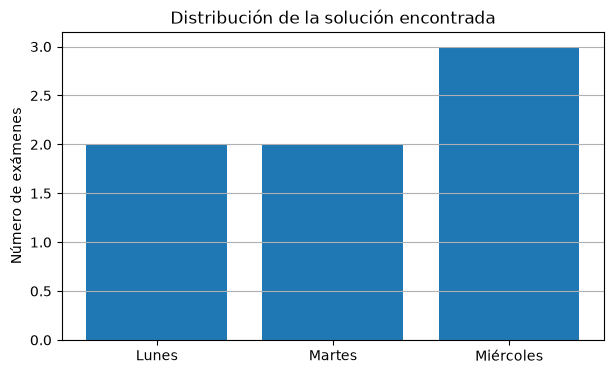

In [7]:
counts = {day: list(solution_fc.values()).count(day) for day in DAYS}
plt.figure(figsize=(7, 4))
plt.bar(counts.keys(), counts.values())
plt.ylabel('Número de exámenes')
plt.title('Distribución de la solución encontrada')
plt.grid(True, axis='y')
plt.show()

## Actividades

### Actividad 1 — Dos días

Cambia el dominio para usar solo lunes y martes. ¿Existe solución? Relaciona el resultado con el coloreo de grafos.

In [8]:
two_day_domains = {var: ['Lunes', 'Martes'] for var in VARIABLES}
solution_two_days, stats_two_days = backtracking_basic(VARIABLES, two_day_domains)
print('Solución:', solution_two_days)
print('Estadísticas:', stats_two_days)


Solución: None
Estadísticas: {'calls': 5, 'failures': 5}


**Discusión (Actividad 1).** Con solo dos días, `solution_two_days` es `None`: no existe una solución consistente. Esto es equivalente al problema de **coloreo de grafos** con 2 colores: cada variable es un nodo y cada restricción es una arista que exige colores (días) distintos entre sus extremos. Un grafo se puede colorear con 2 colores si y solo si es bipartito (no tiene ciclos de longitud impar); el grafo de exámenes definido por `CONSTRAINTS` contiene ciclos impares (por ejemplo, A-B-C-A es un triángulo), así que no es bipartito y, por lo tanto, no admite una 2-coloración — de ahí que no exista un horario válido con solo dos días.

### Actividad 2 — Restricción unaria

El examen `A` solo puede realizarse el lunes. Modifica su dominio antes de iniciar el backtracking.

In [9]:
restricted_domains = {var: DAYS.copy() for var in VARIABLES}
restricted_domains['A'] = ['Lunes']

solution_restricted, stats_restricted = backtracking_basic(VARIABLES, restricted_domains)
print('Solución:', solution_restricted)
print('Estadísticas:', stats_restricted)
print('A quedó asignado a:', solution_restricted['A'])


Solución: {'A': 'Lunes', 'B': 'Martes', 'C': 'Miércoles', 'D': 'Miércoles', 'E': 'Lunes', 'F': 'Martes', 'G': 'Miércoles'}
Estadísticas: {'calls': 9, 'failures': 1}
A quedó asignado a: Lunes


### Actividad 3 — Orden de valores

Implementa **Least Constraining Value (LCV)**: prueba primero el valor que elimina menos opciones de los vecinos.

In [10]:
def order_domain_values(var, assignment, domains):
    def num_conflicts(value):
        count = 0
        for neighbor in neighbors[var]:
            if neighbor in assignment:
                continue
            count += sum(1 for other in domains[neighbor] if other == value)
        return count

    values = legal_values(var, assignment, domains)
    return sorted(values, key=num_conflicts)

print('Orden LCV para C dado A=Lunes:', order_domain_values('C', {'A': 'Lunes'}, domains))


Orden LCV para C dado A=Lunes: ['Martes', 'Miércoles']


### Actividad 4 — Optimización sobre el CSP

Entre todas las soluciones válidas, busca una que minimice el desbalance:

$$
\max_d n_d-\min_d n_d
$$

where $n_d$ is the number of exams assigned to day $d$. Puedes enumerar todas las soluciones con backtracking y conservar la mejor.

Número total de soluciones válidas: 6
Mejor solución balanceada: {'A': 'Lunes', 'B': 'Martes', 'C': 'Miércoles', 'D': 'Miércoles', 'E': 'Lunes', 'F': 'Martes', 'G': 'Miércoles'}
Desbalance: 1


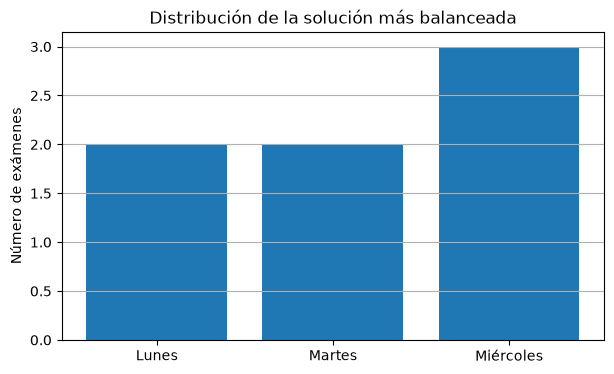

In [11]:
def all_solutions(variables, domains):
    solutions = []

    def backtrack(assignment):
        if len(assignment) == len(variables):
            solutions.append(assignment.copy())
            return

        var = next(v for v in variables if v not in assignment)
        for value in domains[var]:
            assignment[var] = value
            if consistent(assignment):
                backtrack(assignment)
            assignment.pop(var)

    backtrack({})
    return solutions


def imbalance(solution):
    counts = {day: list(solution.values()).count(day) for day in DAYS}
    return max(counts.values()) - min(counts.values())


solutions = all_solutions(VARIABLES, domains)
best_balanced = min(solutions, key=imbalance)

print('Número total de soluciones válidas:', len(solutions))
print('Mejor solución balanceada:', best_balanced)
print('Desbalance:', imbalance(best_balanced))

counts_balanced = {day: list(best_balanced.values()).count(day) for day in DAYS}
plt.figure(figsize=(7, 4))
plt.bar(counts_balanced.keys(), counts_balanced.values())
plt.ylabel('Número de exámenes')
plt.title('Distribución de la solución más balanceada')
plt.grid(True, axis='y')
plt.show()


**Discusión (Actividad 4).** Enumerando todas las soluciones consistentes con `all_solutions` y evaluando el desbalance $\max_d n_d-\min_d n_d$ de cada una, `best_balanced` es la solución con menor desbalance encontrada. A diferencia de la solución obtenida por backtracking básico (que se detiene en la primera solución válida que encuentra y no busca mejorar nada más), aquí exploramos explícitamente todo el espacio de soluciones válidas y elegimos la mejor según una función objetivo, transformando el CSP en un problema de optimización con restricciones.

## Preguntas de cierre

1. ¿Qué información utiliza MRV para seleccionar una variable?
2. ¿Forward checking evita completamente el backtracking?
3. ¿Una solución consistente parcial es necesariamente extensible a una solución completa?
4. ¿Cuándo un CSP se convierte en un problema de optimización?

## Respuestas — Preguntas de cierre

1. **¿Qué información utiliza MRV para seleccionar una variable?** El tamaño del dominio de valores legales que aún le quedan a cada variable no asignada (`legal_values`); MRV escoge la variable con menos valores disponibles, porque es la que tiene mayor probabilidad de fallar pronto y conviene decidirla primero (falla rápido en vez de tarde).
2. **¿Forward checking evita completamente el backtracking?** No. Forward checking detecta más temprano cuando una asignación deja a algún vecino sin valores posibles, reduciendo el número de retrocesos comparado con backtracking básico (compárense `stats_basic` y `stats_fc`), pero no elimina la necesidad de retroceder: solo poda parte del árbol de búsqueda, no garantiza encontrar la solución sin ningún retroceso.
3. **¿Una solución consistente parcial es necesariamente extensible a una solución completa?** No. Una asignación parcial puede ser consistente en el momento (no viola ninguna restricción entre las variables ya asignadas) pero llevar a un callejón sin salida más adelante, donde ninguna extensión futura es consistente; por eso backtracking necesita la capacidad de retroceder.
4. **¿Cuándo un CSP se convierte en un problema de optimización?** Cuando, además de las restricciones que definen qué asignaciones son válidas, se agrega una función objetivo que permite comparar la calidad de las distintas soluciones válidas y buscar la mejor entre ellas, como se hizo en la Actividad 4 al minimizar el desbalance entre días.